In [90]:
#PACKAGES
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             confusion_matrix, roc_auc_score)

In [91]:
# LOAD & COMBINE
files = glob.glob("clean_data/*_final.parquet")

df_list = []
for file in files:
    temp = pd.read_parquet(file)
    coin_name = file.split("/")[-1].replace(".parquet", "").replace("_final", "")
    temp["coin"] = coin_name
    df_list.append(temp)

df = pd.concat(df_list, ignore_index=True)
df["timestamp"] = pd.to_datetime(df["timestamp"])

END_DATE = pd.Timestamp("2022-05-10")

df = df[
    (df["coin"] != "ust") |
    ((df["coin"] == "ust") & (df["timestamp"] <= END_DATE))
    ].copy()

In [92]:
# COIN TYPE MAPPING 
# 3 groups for PCA — fiat_backed is pooled (3 coins)
# crypto_backed (DAI) and algorithmic (UST) are individual PCA
COIN_TYPES = {
    "usdt": "fiat_backed",
    "usdc": "fiat_backed",
    "pax":  "fiat_backed",
    "dai":  "crypto_backed",
    "ust":  "algorithmic",
}
df["coin_type"] = df["coin"].map(COIN_TYPES)

# coins with test depeg events
EVAL_COINS = ["usdc", "dai", "ust", "pax", "usdt"]

In [93]:
# FEATURES
COIN_FEATURES = [
    'percent_change_24h', 'percent_change_7d', 'percent_change_30d',
    'volume_percent_change_24h', 'volume_percent_change_7d', 'volume_percent_change_30d',
    'market_cap_percent_change_24h', 'market_cap_percent_change_7d', 'market_cap_percent_change_30d',
    'circulating_supply_percent_change_24h', 'circulating_supply_percent_change_7d',
    'circulating_supply_percent_change_30d',
    'realized_daily_volatility',
]

MACRO_FEATURES = [
    'fear_greed_index',
    'fed_funds_rate'
]

features = COIN_FEATURES + MACRO_FEATURES

In [94]:
# CLEAN FEATURES
def clean_features(df, features):
    df = df.copy()
    df[features] = df[features].replace([np.inf, -np.inf], np.nan)
    df[features] = (
        df.groupby("coin")[features]
        .transform(lambda x: x.ffill().bfill())
        .fillna(0)
    )
    return df

In [95]:
# CLIP OUTLIERS
def clip_outliers(df_train, df_test, features, n_std=5):
    df_train = df_train.copy()
    df_test  = df_test.copy()
    for col in features:
        mean = df_train[col].mean()
        std  = df_train[col].std()
        lo, hi = mean - n_std * std, mean + n_std * std
        df_train[col] = df_train[col].clip(lo, hi)
        df_test[col]  = df_test[col].clip(lo, hi)
    return df_train, df_test

In [96]:
# GLOBAL SPLIT
POOLED_SPLIT_DATE = "2021-10-01"

def split_by_date(df, split_date, date_col="timestamp"):
    df = df.sort_values(date_col).reset_index(drop=True).copy()
    split_date = pd.Timestamp(split_date)
    train = df[df[date_col] <= split_date].copy()
    test  = df[df[date_col] > split_date].copy()
    return train, test

df_train, df_test = split_by_date(df, POOLED_SPLIT_DATE)

# clean after split to avoid fill leakage across boundary
df_train = clean_features(df_train, features)
df_test  = clean_features(df_test,  features)

# clip outliers
df_train, df_test = clip_outliers(df_train, df_test, features, n_std=5)

print(f"Data range: {df['timestamp'].min().date()} → {df['timestamp'].max().date()}")
print(f"Train: {df_train.shape} | Test: {df_test.shape}")
print("\nTrain coin counts:"); print(df_train["coin"].value_counts())
print("\nTest coin counts:");  print(df_test["coin"].value_counts())
print("\nTest depeg events (3d):")
print(df_test.groupby("coin")["depeg"].value_counts().unstack(fill_value=0))

Data range: 2020-12-25 → 2026-03-19
Train: (1400, 45) | Test: (6745, 45)

Train coin counts:
ust     280
usdc    280
dai     280
usdt    280
pax     280
Name: coin, dtype: int64

Test coin counts:
usdc    1631
usdt    1631
pax     1631
dai     1631
ust      221
Name: coin, dtype: int64

Test depeg events (3d):
depeg     0   1
coin           
dai    1617  14
pax    1600  31
usdc   1618  13
usdt   1613  18
ust     214   7


In [97]:
train_depegs = df_train.groupby("coin")["depeg"].sum()
test_depegs  = df_test.groupby("coin")["depeg"].sum()

depeg_compare = pd.concat(
    [train_depegs, test_depegs],
    axis=1,
    keys=["train_depegs", "test_depegs"]
).fillna(0)

print("\nDepeg counts per coin:")
print(depeg_compare)


Depeg counts per coin:
      train_depegs  test_depegs
coin                           
dai              9           14
pax              4           31
usdc            19           13
usdt            10           18
ust             25            7


In [98]:
for split_name, split_df in [("train", df_train), ("test", df_test)]:
    for col in features:
        bad = (~np.isfinite(split_df[col])).sum()
        if bad > 0:
            print(f"{split_name} {col}: {bad} bad values remaining")

In [99]:
# HYBRID SCALING
# coin features -> per-coin StandardScaler fitted on train only
# macro features -> single global StandardScaler fitted on train only

coin_scalers = {}
scaled_train_list = []
scaled_test_list  = []

for coin, group in df_train.groupby("coin"):
    scaler = StandardScaler()
    scaled = group.copy()
    scaled[COIN_FEATURES] = scaler.fit_transform(group[COIN_FEATURES])
    coin_scalers[coin] = scaler
    scaled_train_list.append(scaled)

for coin, group in df_test.groupby("coin"):
    scaled = group.copy()
    scaled[COIN_FEATURES] = coin_scalers[coin].transform(group[COIN_FEATURES])
    scaled_test_list.append(scaled)

df_train_scaled = pd.concat(scaled_train_list).sort_values("timestamp").reset_index(drop=True)
df_test_scaled  = pd.concat(scaled_test_list).sort_values("timestamp").reset_index(drop=True)

# global scaler for macro features
macro_scaler = StandardScaler()
df_train_scaled[MACRO_FEATURES] = macro_scaler.fit_transform(df_train_scaled[MACRO_FEATURES])
df_test_scaled[MACRO_FEATURES]  = macro_scaler.transform(df_test_scaled[MACRO_FEATURES])

In [100]:
# HYBRID POOLED PCA BY COIN TYPE
# fiat_backed  → genuinely pooled PCA (USDT, USDC, PAX)
# crypto_backed → individual PCA (DAI only)
# algorithmic  → individual PCA (UST only)

N_COMPONENTS = 0.95

pca_models = {}

for coin_type, group_df in df_train_scaled.groupby("coin_type"):
    X = group_df[features].values
    pca = PCA(n_components=N_COMPONENTS, random_state=42)
    pca.fit(X)
    pca_models[coin_type] = pca
    coins_in_group = group_df["coin"].unique().tolist()
    print(f"{coin_type} {coins_in_group}: {pca.n_components_} components, "
          f"cumulative variance = {pca.explained_variance_ratio_.cumsum()[-1]:.4f}")

algorithmic ['ust']: 10 components, cumulative variance = 0.9542
crypto_backed ['dai']: 10 components, cumulative variance = 0.9547
fiat_backed ['usdc', 'usdt', 'pax']: 11 components, cumulative variance = 0.9708


In [101]:
# RECONSTRUCTION ERROR
def compute_recon_error(df_scaled, pca_models, features):
    df_scaled = df_scaled.copy()
    df_scaled["recon_error"] = np.nan
    for coin_type, group_df in df_scaled.groupby("coin_type"):
        pca     = pca_models[coin_type]
        X       = group_df[features].values
        X_recon = pca.inverse_transform(pca.transform(X))
        df_scaled.loc[group_df.index, "recon_error"] = np.mean((X - X_recon) ** 2, axis=1)
    return df_scaled

df_train_scaled = compute_recon_error(df_train_scaled, pca_models, features)
df_test_scaled  = compute_recon_error(df_test_scaled,  pca_models, features)

print("\nTrain recon_error stats:")
print(df_train_scaled.groupby("coin")["recon_error"].describe().round(4))
print("\nTest recon_error stats:")
print(df_test_scaled.groupby("coin")["recon_error"].describe().round(4))


Train recon_error stats:
      count    mean     std     min     25%     50%     75%     max
coin                                                               
dai   280.0  0.0453  0.0696  0.0001  0.0099  0.0236  0.0528  0.7320
pax   280.0  0.0367  0.1993  0.0000  0.0012  0.0054  0.0249  3.2288
usdc  280.0  0.0248  0.1311  0.0000  0.0010  0.0044  0.0136  2.0957
usdt  280.0  0.0261  0.1069  0.0000  0.0015  0.0050  0.0187  1.6505
ust   280.0  0.0458  0.0878  0.0001  0.0078  0.0200  0.0471  0.9443

Test recon_error stats:
       count    mean     std     min     25%     50%     75%      max
coin                                                                 
dai   1631.0  0.1224  0.5366  0.0001  0.0159  0.0323  0.0740  12.8751
pax   1631.0  0.0961  0.1807  0.0000  0.0072  0.0307  0.1056   2.2456
usdc  1631.0  0.0904  1.1719  0.0000  0.0078  0.0191  0.0359  35.7442
usdt  1631.0  0.0426  0.1884  0.0000  0.0064  0.0208  0.0448   7.1790
ust    221.0  0.0588  0.1159  0.0000  0.0117  0.0276 

In [102]:
# THRESHOLD SEARCH
# search per coin type so each group finds its own optimal threshold
# PAX and USDT excluded from precision/recall since no test depeg events

print("\nThreshold search by coin type:")
for coin_type, group_df in df_test_scaled.groupby("coin_type"):
    train_group = df_train_scaled[df_train_scaled["coin_type"] == coin_type]
    test_group  = df_test_scaled[df_test_scaled["coin_type"] == coin_type]
    eval_group  = test_group[test_group["coin"].isin(EVAL_COINS)]

    if eval_group.empty:
        continue

    print(f"\n  {coin_type}:")
    for p in [0.90, 0.93, 0.95, 0.97, 0.99]:
        thresholds_ct = train_group.groupby("coin")["recon_error"].quantile(p).to_dict()
        eval_group = eval_group.copy()
        eval_group["anomaly"] = (
                eval_group["recon_error"] > eval_group["coin"].map(thresholds_ct)
        ).astype(int)

        precision_avg = eval_group.groupby("coin").apply(
            lambda g: precision_score(g["depeg"], g["anomaly"], zero_division=0)
        ).mean()
        recall_avg = eval_group.groupby("coin").apply(
            lambda g: recall_score(g["depeg"], g["anomaly"], zero_division=0)
        ).mean()
        f1_avg = eval_group.groupby("coin").apply(
            lambda g: f1_score(g["depeg"], g["anomaly"], zero_division=0)
        ).mean()
        print(f"    p={p}  precision={precision_avg:.4f}  recall={recall_avg:.4f}  f1={f1_avg:.4f}")


Threshold search by coin type:

  algorithmic:
    p=0.9  precision=0.0400  recall=0.1429  f1=0.0625
    p=0.93  precision=0.0714  recall=0.1429  f1=0.0952
    p=0.95  precision=0.0769  recall=0.1429  f1=0.1000
    p=0.97  precision=0.0833  recall=0.1429  f1=0.1053
    p=0.99  precision=0.2500  recall=0.1429  f1=0.1818

  crypto_backed:
    p=0.9  precision=0.0381  recall=0.8571  f1=0.0729
    p=0.93  precision=0.0476  recall=0.8571  f1=0.0902
    p=0.95  precision=0.0574  recall=0.8571  f1=0.1076
    p=0.97  precision=0.0667  recall=0.7857  f1=0.1229
    p=0.99  precision=0.0638  recall=0.4286  f1=0.1111

  fiat_backed:
    p=0.9  precision=0.0274  recall=0.5040  f1=0.0520
    p=0.93  precision=0.0342  recall=0.4676  f1=0.0637
    p=0.95  precision=0.0481  recall=0.4490  f1=0.0864
    p=0.97  precision=0.0755  recall=0.3619  f1=0.1239
    p=0.99  precision=0.1606  recall=0.2818  f1=0.1966


In [103]:
#EVALUATION
def evaluate(df_test_scaled, thresholds, label_col, eval_coins):
    df_test_scaled = df_test_scaled.copy()
    df_test_scaled["anomaly"] = (
            df_test_scaled["recon_error"] > df_test_scaled["coin"].map(thresholds)
    ).astype(int)

    # only evaluate coins with test depeg events
    df_eval = df_test_scaled[df_test_scaled["coin"].isin(eval_coins)].copy()

    results = []
    for coin, group in df_eval.groupby("coin"):
        y_true = group[label_col].astype(bool)
        y_pred = group["anomaly"]

        precision   = precision_score(y_true, y_pred, zero_division=0)
        recall      = recall_score(y_true, y_pred, zero_division=0)
        f1          = f1_score(y_true, y_pred, zero_division=0)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

        try:
            auc = roc_auc_score(y_true, group["recon_error"])
        except ValueError:
            auc = np.nan

        results.append({
            "coin":          coin,
            "coin_type":     COIN_TYPES.get(coin, "unknown"),
            "precision":     round(precision,   4),
            "recall":        round(recall,      4),
            "f1":            round(f1,          4),
            "specificity":   round(specificity, 4),
            "auc_roc":       round(auc, 4) if not np.isnan(auc) else np.nan,
            "n_anomalies":   int(y_pred.sum()),
            "n_true_depegs": int(y_true.sum()),
            "threshold":     round(thresholds.get(coin, np.nan), 6)
        })

    return pd.DataFrame(results)

In [104]:
# FINAL EVALUATION 
# per coin threshold
THRESHOLD_PERCENTILE = 0.99

thresholds = df_train_scaled.groupby("coin")["recon_error"].quantile(THRESHOLD_PERCENTILE).to_dict()

print("\n── Results: depeg_future_1d ──")
results_3d = evaluate(df_test_scaled, thresholds, "depeg_future_1d", EVAL_COINS)
print(results_3d.to_string(index=False))

print("\n── Results: depeg_future_3d──")
results_3d = evaluate(df_test_scaled, thresholds, "depeg_future_3d", EVAL_COINS)
print(results_3d.to_string(index=False))

print("\n── Results: depeg_future_7d ──")
results_7d = evaluate(df_test_scaled, thresholds, "depeg_future_7d", EVAL_COINS)
print(results_7d.to_string(index=False))

print("\n── Results: depeg_future_14d ──")
results_7d = evaluate(df_test_scaled, thresholds, "depeg_future_14d", EVAL_COINS)
print(results_7d.to_string(index=False))


── Results: depeg_future_1d ──
coin     coin_type  precision  recall     f1  specificity  auc_roc  n_anomalies  n_true_depegs  threshold
 dai crypto_backed     0.0426  0.2857 0.0741       0.9443   0.7915           94             14   0.304495
 pax   fiat_backed     0.0560  0.2258 0.0897       0.9262   0.6336          125             31   0.319177
usdc   fiat_backed     0.2000  0.2308 0.2143       0.9926   0.6729           15             13   0.225077
usdt   fiat_backed     0.1290  0.2222 0.1633       0.9833   0.7433           31             18   0.205947
 ust   algorithmic     0.2500  0.1250 0.1667       0.9859   0.6156            4              8   0.423288

── Results: depeg_future_3d──
coin     coin_type  precision  recall     f1  specificity  auc_roc  n_anomalies  n_true_depegs  threshold
 dai crypto_backed     0.1489  0.4242 0.2205       0.9499   0.8637           94             33   0.304495
 pax   fiat_backed     0.2000  0.3049 0.2415       0.9354   0.7175          125          

In [105]:
# =========================
# INDIVIDUAL PC EVALUATION
# =========================

def compute_recon_error_subset(df_scaled, pca_models, features, pc_index):
    df_scaled = df_scaled.copy()
    df_scaled["recon_error_subset"] = np.nan

    for coin_type, group_df in df_scaled.groupby("coin_type"):
        pca = pca_models[coin_type]
        X = group_df[features].values

        Z = pca.transform(X)

        # keep only ONE PC
        Z_subset = np.zeros_like(Z)
        Z_subset[:, pc_index] = Z[:, pc_index]

        X_recon = pca.inverse_transform(Z_subset)

        err = np.mean((X - X_recon) ** 2, axis=1)
        df_scaled.loc[group_df.index, "recon_error_subset"] = err

    return df_scaled


results_pc = []

for coin_type, pca in pca_models.items():
    n = pca.n_components_

    train_ct = df_train_scaled[df_train_scaled["coin_type"] == coin_type]
    test_ct  = df_test_scaled[df_test_scaled["coin_type"] == coin_type]

    for i in range(n):
        train_temp = compute_recon_error_subset(train_ct, pca_models, features, i)
        test_temp  = compute_recon_error_subset(test_ct,  pca_models, features, i)

        thresholds = train_temp.groupby("coin")["recon_error_subset"].quantile(0.99).to_dict()

        eval_df = test_temp[test_temp["coin"].isin(EVAL_COINS)].copy()
        eval_df["anomaly"] = (
            eval_df["recon_error_subset"] > eval_df["coin"].map(thresholds)
        ).astype(int)

        f1 = eval_df.groupby("coin").apply(
            lambda g: f1_score(g["depeg"], g["anomaly"], zero_division=0)
        ).mean()

        results_pc.append({
            "coin_type": coin_type,
            "pc": f"PC{i+1}",
            "pc_index": i,
            "f1": f1
        })

results_df = pd.DataFrame(results_pc)

# sort and get top 3
results_df_sorted = results_df.sort_values(["coin_type", "f1"], ascending=[True, False])
top3_pcs = results_df_sorted.groupby("coin_type").head(3)

print("\nTop 3 PCs by coin type:")
print(top3_pcs)

top3_summary = top3_pcs.groupby("coin_type")["pc"].apply(list)
print("\nTop 3 PC names per coin type:")
print(top3_summary)


Top 3 PCs by coin type:
        coin_type    pc  pc_index        f1
2     algorithmic   PC3         2  0.285714
0     algorithmic   PC1         0  0.250000
1     algorithmic   PC2         1  0.250000
13  crypto_backed   PC4         3  0.263158
14  crypto_backed   PC5         4  0.235294
19  crypto_backed  PC10         9  0.235294
23    fiat_backed   PC4         3  0.187361
20    fiat_backed   PC1         0  0.186789
21    fiat_backed   PC2         1  0.175099

Top 3 PC names per coin type:
coin_type
algorithmic       [PC3, PC1, PC2]
crypto_backed    [PC4, PC5, PC10]
fiat_backed       [PC4, PC1, PC2]
Name: pc, dtype: object


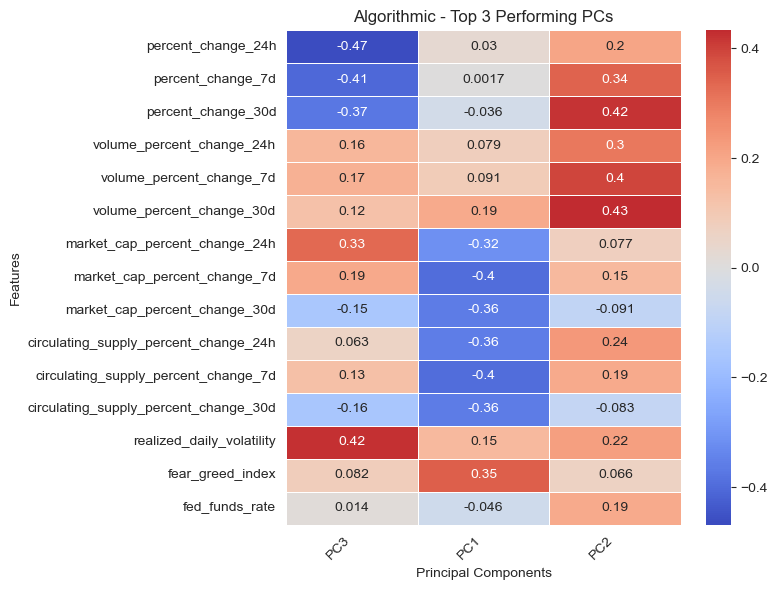

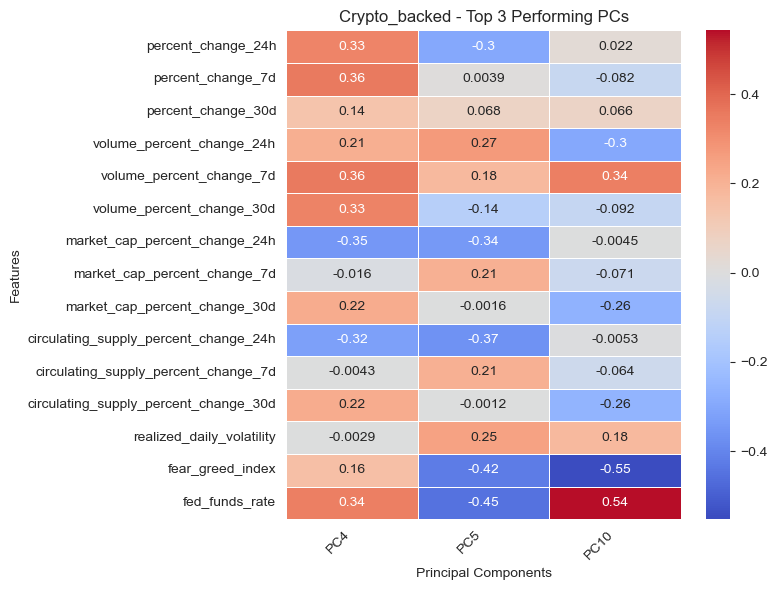

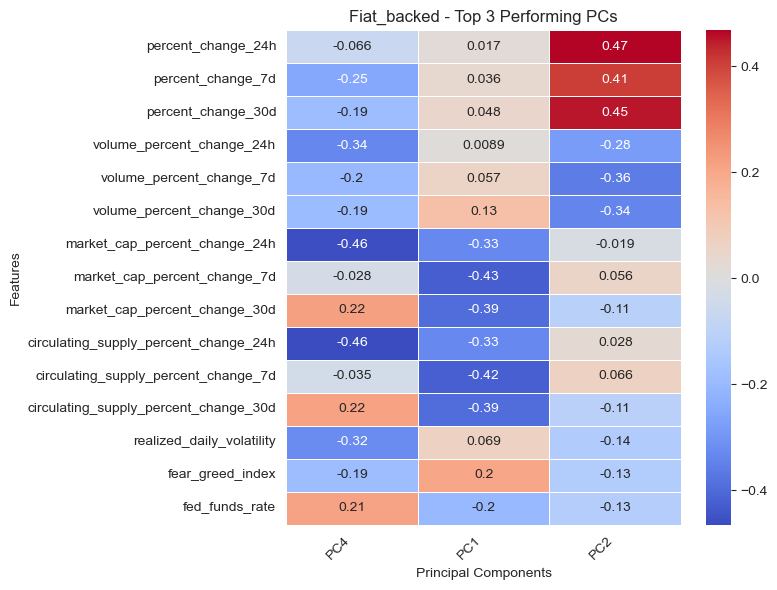

In [106]:
# =========================
# HEATMAPS FOR TOP 3 PCs
# =========================

import seaborn as sns

for coin_type, pca in pca_models.items():
    
    pcs = top3_pcs[top3_pcs["coin_type"] == coin_type]["pc_index"].tolist()
    
    if len(pcs) == 0:
        continue

    loadings_df = pd.DataFrame(
        pca.components_.T,
        index=features,
        columns=[f'PC{i+1}' for i in range(pca.n_components_)]
    )

    selected_cols = [f'PC{i+1}' for i in pcs]
    loadings_top3 = loadings_df[selected_cols]

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        loadings_top3,
        cmap='coolwarm',
        center=0,
        annot=True,
        linewidths=0.5
    )

    plt.title(f"{coin_type.capitalize()} - Top 3 Performing PCs")
    plt.xlabel("Principal Components")
    plt.ylabel("Features")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

In [107]:
print(df.groupby("coin")["depeg"].value_counts().unstack(fill_value=0))

depeg     0   1
coin           
dai    1888  23
pax    1876  35
usdc   1879  32
usdt   1883  28
ust     469  32


In [108]:
#check depeg events
for coin, group in df.groupby("coin"):
    depegs = group[group["depeg"] == 1]["timestamp"]
    print(f"{coin}: {len(depegs)} depegs | earliest={depegs.min().date()} | latest={depegs.max().date()}")

dai: 23 depegs | earliest=2021-01-01 | latest=2023-03-12
pax: 35 depegs | earliest=2021-04-17 | latest=2024-07-01
usdc: 32 depegs | earliest=2021-01-07 | latest=2023-03-21
usdt: 28 depegs | earliest=2021-01-05 | latest=2026-02-04
ust: 32 depegs | earliest=2020-12-30 | latest=2022-05-09


Limitation of doing a global split:
Dropping PAX and USDT from depeg evaluation, keep them in PCA. They contribute to learning the fiat-backed covariance structure in PCA, but since they have no test depegs you just can't evaluate anomaly detection on them.
